In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
DATA_FOLDER  = r"C:\AAKASH\MS_NOTES\THESIS\Material\Data\recordings\sequence_model\data"
MODEL_FOLDER = r"C:\AAKASH\MS_NOTES\THESIS\Material\Data\recordings\sequence_model\model_output"

N_FEATURES   = 25
N_CLASSES    = 3        # 0=White, 1=Black, 2=Draw
BATCH_SIZE   = 16
EPOCHS       = 20
LR           = 1e-3

In [ ]:
class FoosballDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, seq_len, 24)
        self.y = torch.tensor(y, dtype=torch.long)       # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]                  # (seq_len, 24)
        x = x.permute(1, 0)             # (24, seq_len) Conv1D format
        return x, self.y[idx]

In [4]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()

        # padding = (kernel_size-1)*dilation keeps output same length as input
        pad = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels,kernel_size, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_channels, out_channels,kernel_size, dilation=dilation, padding=pad)

        self.bn1   = nn.BatchNorm1d(out_channels)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.drop1 = nn.Dropout(p=0.4)
        self.drop2 = nn.Dropout(p=0.4)

        # Residual connection
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        out = self.conv1(x)
        out = out[:, :, :x.shape[2]]
        out = self.bn1(out)
        out = F.relu(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = out[:, :, :x.shape[2]]
        out = self.bn2(out)
        out = F.relu(out)
        out = self.drop2(out)

        return F.relu(out + self.residual(x))


class TCN(nn.Module):
    def __init__(self, n_features=N_FEATURES, n_classes=N_CLASSES, n_channels=16, kernel_size=3, n_blocks=3):
        super().__init__()

        layers = []
        in_ch  = n_features

        for i in range(n_blocks):
            dilation = 2 ** i
            layers.append(TCNBlock(in_ch, n_channels, kernel_size, dilation))
            in_ch = n_channels

        self.network    = nn.Sequential(*layers)
        self.classifier = nn.Linear(n_channels, n_classes)

    def forward(self, x):
        out = self.network(x)
        out = out.mean(dim=2)
        return self.classifier(out)

In [5]:
def train_model(model, train_loader, val_loader, class_weights, model_name):
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_val_acc = 0.0
    best_path    = os.path.join(MODEL_FOLDER, f"{model_name}_best.pt")

    # history — collect per epoch
    history = {
        'train_loss': [],
        'val_loss'  : [],
        'train_acc' : [],
        'val_acc'   : []
    }

    print(f"Training: {model_name}")
    print(f"Device:   {device}")
    print(f"Params:   {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'Epoch':>6}{'TrainLoss':>10}{'TrainAcc':>9}{'ValLoss':>8}{'ValAcc':>7}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss    = 0.0
        train_correct = 0
        train_total   = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits  = model(X_batch)
            loss    = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * len(y_batch)
            preds          = logits.argmax(dim=1)
            train_correct += (preds == y_batch).sum().item()
            train_total   += len(y_batch)

        train_loss = train_loss / train_total
        train_acc  = train_correct / train_total

        model.eval()
        val_loss    = 0.0
        val_correct = 0
        val_total   = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch     = X_batch.to(device)
                y_batch     = y_batch.to(device)
                logits      = model(X_batch)
                loss        = criterion(logits, y_batch)
                val_loss   += loss.item() * len(y_batch)
                preds       = logits.argmax(dim=1)
                val_correct += (preds == y_batch).sum().item()
                val_total   += len(y_batch)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total

        scheduler.step(val_loss)

        # collect history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            tag = " <- saved"
        else:
            tag = ""

        print(f"{epoch:6d}{train_loss:10.4f}{train_acc:9.3f}{val_loss:8.4f}{val_acc:7.3f}{tag}")

    print(f"\nBest val accuracy: {best_val_acc:.3f}")
    print(f"Model saved to:    {best_path}")
    return best_path, history

In [ ]:
def evaluate_model(model, model_path, test_loader, model_name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch)
            probs   = F.softmax(logits, dim=1)
            preds   = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    accuracy   = (all_preds == all_labels).mean()

    label_names = {0: 'White', 1: 'Black', 2: 'Draw'}

    print(f"\n{'x'*100}")
    print(f"TEST RESULTS — {model_name}")

    print(f"Overall Accuracy: {accuracy:.3f}  ({int(accuracy*len(all_labels))}/{len(all_labels)} correct)")

    print(f"\nPer-class accuracy:")
    for cls in [0, 1, 2]:
        mask    = all_labels == cls
        if mask.sum() == 0:
            continue
        cls_acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {label_names[cls]:5s}: {cls_acc:.3f}  ({mask.sum()} sequences)")

    print(f"\nDetailed predictions:")
    print(f"  {'':2}  {'True':5}  {'Pred':5}  {'White%':7}  {'Black%':7}  {'Draw%':6}")
    for i in range(len(all_labels)):
        true = label_names[all_labels[i]]
        pred = label_names[all_preds[i]]
        w    = all_probs[i][0] * 100
        b    = all_probs[i][1] * 100
        d    = all_probs[i][2] * 100
        mark = "\u2713" if all_preds[i] == all_labels[i] else "\u2717"
        print(f"  {mark}   {true:5}  {pred:5}  {w:6.1f}%  {b:6.1f}%  {d:5.1f}%")

    return accuracy, all_preds, all_labels, all_probs

In [ ]:
def hard_vote(all_preds, all_labels, n_videos=8, seqs_per_vid=6):
    label_names  = {0: 'White', 1: 'Black', 2: 'Draw'}
    hard_correct = 0
    print(f"\nHARD VOTE")
    for v in range(n_videos):
        s          = v * seqs_per_vid
        e          = s + seqs_per_vid
        votes      = np.bincount(all_preds[s:e], minlength=3)
        final_pred = votes.argmax()
        true_label = all_labels[s]
        mark       = "\u2713" if final_pred == true_label else "\u2717"
        hard_correct += (final_pred == true_label)
        print(f"Video {v+1}: votes W={votes[0]} B={votes[1]} D={votes[2]} "f"pred={label_names[final_pred]:5s}  true={label_names[true_label]:5s}  {mark}")
    hard_acc = hard_correct / n_videos
    print(f"\n  Hard accuracy: {hard_correct}/{n_videos} = {hard_acc:.3f}")
    return hard_acc


def soft_vote(all_probs, all_labels, n_videos=8, seqs_per_vid=6):
    label_names  = {0: 'White', 1: 'Black', 2: 'Draw'}
    soft_correct = 0
    print(f"\nSOFT VOTE")
    for v in range(n_videos):
        s          = v * seqs_per_vid
        e          = s + seqs_per_vid
        avg_probs  = all_probs[s:e].mean(axis=0)
        final_pred = avg_probs.argmax()
        true_label = all_labels[s]
        mark       = "\u2713" if final_pred == true_label else "\u2717"
        soft_correct += (final_pred == true_label)
        print(f"Video {v+1}: avg W={avg_probs[0]:.2f} B={avg_probs[1]:.2f} D={avg_probs[2]:.2f}"f"pred={label_names[final_pred]:5s}  true={label_names[true_label]:5s}  {mark}")
    soft_acc = soft_correct / n_videos
    print(f"\n  Soft accuracy: {soft_correct}/{n_videos} = {soft_acc:.3f}")
    return soft_acc

In [ ]:
def plot_training_curve(history, seed, save_folder):
    epochs     = range(1, len(history['train_loss']) + 1)
    best_epoch = int(np.argmax(history['val_acc'])) + 1   # argmax finds index of max val_acc

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curves — Seed {seed}', fontsize=14, fontweight='bold')

    # LEFT — Loss
    ax1.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
    ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
    ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5,label=f'Best Epoch ({best_epoch})')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # RIGHT — Accuracy
    ax2.plot(epochs, history['train_acc'], label='Train Acc', color='steelblue', linewidth=2)
    ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='tomato',    linewidth=2)
    ax2.axhline(y=0.333, color='gray', linestyle=':', linewidth=1.5, label='Random baseline (0.333)')
    ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5,label=f'Best Epoch ({best_epoch})')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, f'training_curve_seed{seed}.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(all_preds, all_labels, seed, save_folder):
    class_names = ['White', 'Black', 'Draw']
    cm          = confusion_matrix(all_labels, all_preds)
    cm_pct      = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row percentages

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — Seed {seed}', fontsize=14, fontweight='bold')

    # LEFT — raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names,ax=ax1, linewidths=0.5, cbar=True)
    ax1.set_title('Counts')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    # RIGHT — row percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',xticklabels=class_names, yticklabels=class_names,ax=ax2, linewidths=0.5, cbar=True,vmin=0, vmax=100)
    ax2.set_title('Row % (per true class)')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, f'confusion_matrix_seed{seed}.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_probability_distribution(all_probs, all_labels, seed, save_folder):
    class_names = ['White', 'Black', 'Draw']
    colors      = ['royalblue', 'tomato', 'mediumseagreen']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Predicted Probability Distributions — Seed {seed}', fontsize=14, fontweight='bold')

    for true_cls in range(3):
        mask      = all_labels == true_cls
        probs_cls = all_probs[mask]          
        ax        = axes[true_cls]

        for pred_cls in range(3):
            ax.hist(probs_cls[:, pred_cls], bins=15, alpha=0.6,label=f'P({class_names[pred_cls]})',color=colors[pred_cls], edgecolor='white')

        ax.axvline(x=0.333, color='black', linestyle='--', linewidth=1.2, label='Random (0.333)')
        ax.set_title(f'True class = {class_names[true_cls]} ({mask.sum()} seqs)')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, f'prob_distribution_seed{seed}.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_voting_results(all_preds, all_probs, all_labels, seed, save_folder, n_videos=8, seqs_per_vid=6):
    class_names  = ['White', 'Black', 'Draw']
    label_names  = {0: 'White', 1: 'Black', 2: 'Draw'}
    video_labels = [f'V{v+1}' for v in range(n_videos)]

    hard_preds = []
    soft_preds = []
    true_labels = []

    for v in range(n_videos):
        s = v * seqs_per_vid
        e = s + seqs_per_vid
        hard_preds.append(np.bincount(all_preds[s:e], minlength=3).argmax())
        soft_preds.append(all_probs[s:e].mean(axis=0).argmax())
        true_labels.append(all_labels[s])

    hard_preds  = np.array(hard_preds)
    soft_preds  = np.array(soft_preds)
    true_labels = np.array(true_labels)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Video-Level Voting Results — Seed {seed}', fontsize=14, fontweight='bold')

    for ax, preds, title in [(axes[0], hard_preds, 'Hard Vote'),(axes[1], soft_preds, 'Soft Vote')]:
        colors = ['green' if p == t else 'tomato' for p, t in zip(preds, true_labels)]
        bars   = ax.bar(video_labels, [1]*n_videos, color=colors, edgecolor='white', linewidth=0.8)

        for i, (bar, p, t) in enumerate(zip(bars, preds, true_labels)):
            ax.text(bar.get_x() + bar.get_width()/2, 0.5,f'Pred:\n{label_names[p]}\nTrue:\n{label_names[t]}',ha='center', va='center', fontsize=7.5, fontweight='bold', color='white')

        correct = (preds == true_labels).sum()
        ax.set_title(f'{title}  ({correct}/{n_videos} correct = {correct/n_videos:.3f})')
        ax.set_xlabel('Video')
        ax.set_yticks([])
        ax.grid(False)

        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(color='green', label='Correct'),Patch(color='tomato', label='Wrong')],loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, f'voting_results_seed{seed}.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_seed_summary(seed_results, seeds, save_folder):
    x      = np.arange(len(seeds))
    width  = 0.2
    labels = [str(s) for s in seeds]
    colors = ['steelblue', 'tomato', 'mediumseagreen', 'mediumpurple']
    keys   = ['overall', 'white', 'black', 'draw']
    names  = ['Overall', 'White', 'Black', 'Draw']

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Per-Seed Accuracy by Class', fontsize=14, fontweight='bold')

    for i, (key, name, color) in enumerate(zip(keys, names, colors)):
        ax.bar(x + i*width, seed_results[key], width, label=name, color=color, alpha=0.85, edgecolor='white')

    ax.axhline(y=0.333, color='black', linestyle=':', linewidth=1.5, label='Random baseline')
    ax.set_xlabel('Seed')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, 'per_seed_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_mean_std_summary(seed_results, save_folder):
    keys   = ['overall', 'white', 'black', 'draw', 'hard_vote', 'soft_vote']
    names  = ['Overall', 'White', 'Black', 'Draw', 'Hard Vote', 'Soft Vote']
    colors = ['steelblue', 'cornflowerblue', 'tomato', 'mediumseagreen', 'darkorange', 'mediumpurple']

    means  = [np.mean(seed_results[k]) for k in keys]
    stds   = [np.std(seed_results[k])  for k in keys]

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('Mean \u00b1 Std Accuracy Across 5 Seeds', fontsize=14, fontweight='bold')

    bars = ax.bar(names, means, yerr=stds, capsize=6,color=colors, alpha=0.85, edgecolor='white',error_kw={'linewidth': 2, 'ecolor': 'black'})

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.015,f'{mean:.3f}\n\u00b1{std:.3f}',ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.axhline(y=0.333, color='black', linestyle=':', linewidth=1.5, label='Random baseline (0.333)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, 'mean_std_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_final_comparison(seed_results, save_folder):
    categories = ['Sequence\nLevel', 'Hard Vote\n(Video)', 'Soft Vote\n(Video)']
    keys       = ['overall', 'hard_vote', 'soft_vote']
    colors     = ['steelblue', 'darkorange', 'mediumpurple']

    means = [np.mean(seed_results[k]) for k in keys]
    stds  = [np.std(seed_results[k])  for k in keys]

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle('Final Accuracy Comparison — Sequence vs Video Level', fontsize=13, fontweight='bold')

    bars = ax.bar(categories, means, yerr=stds, capsize=8,color=colors, alpha=0.85, edgecolor='white', width=0.45,error_kw={'linewidth': 2, 'ecolor': 'black'})

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,f'{mean:.3f} \u00b1 {std:.3f}',ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.axhline(y=0.333, color='black', linestyle=':', linewidth=1.5, label='Random baseline (0.333)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_folder, 'final_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

Loading data...
X_train: (294, 283, 25)  y_train: (294,)
X_test:  (48, 283, 25)   y_test:  (48,)

Class counts  — White: 162, Black: 48, Draw: 84
Class weights — White: 0.605, Black: 2.042, Draw: 1.167

SEED 42
TCN parameters: 5,795
Training: TCN_seed42
Device:   cpu
Params:   5,795
 Epoch TrainLoss TrainAcc ValLoss ValAcc
     1    1.1714    0.177  1.1287  0.250 <- saved
     2    1.0872    0.285  1.1636  0.250
     3    1.0259    0.524  1.2253  0.208
     4    0.9929    0.517  1.3418  0.271 <- saved
     5    0.9912    0.472  1.3435  0.312 <- saved
     6    0.9630    0.538  1.4408  0.333 <- saved
     7    0.9576    0.510  1.2468  0.292
     8    0.9501    0.503  1.3556  0.438 <- saved
     9    0.9376    0.528  1.4019  0.396
    10    0.9205    0.556  1.3870  0.333
    11    0.8979    0.576  1.3833  0.312
    12    0.8881    0.583  1.3915  0.458 <- saved
    13    0.9047    0.531  1.3843  0.500 <- saved
    14    0.8800    0.580  1.3990  0.417
    15    0.9066    0.569  1.3570  0.3

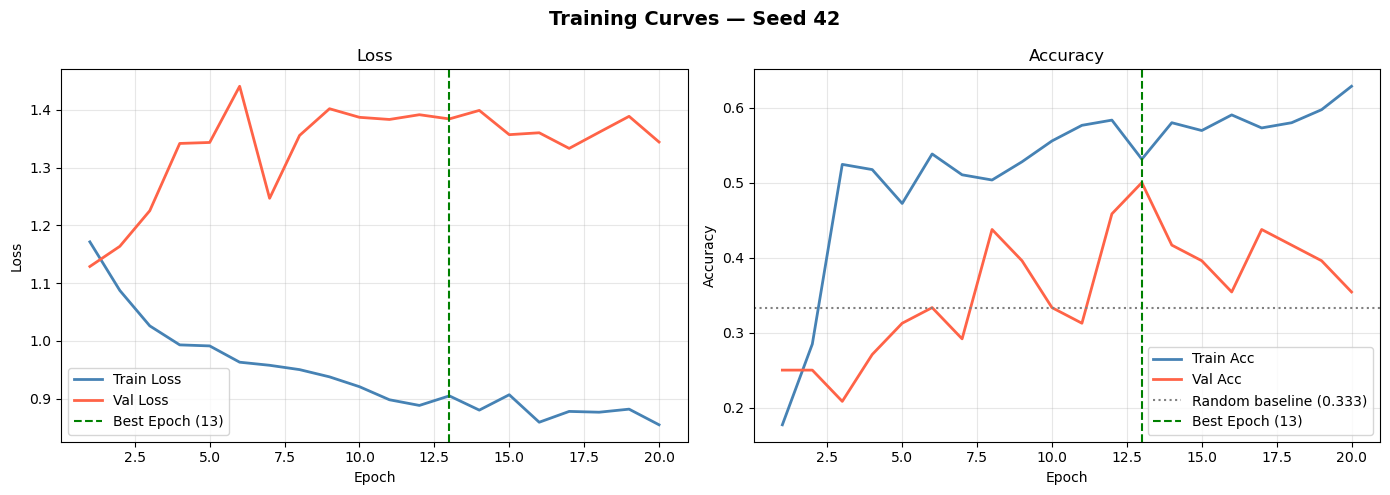


TEST RESULTS — TCN_seed42
Overall Accuracy: 0.500  (24/48 correct)

Per-class accuracy:
  White: 0.667  (18 sequences)
  Black: 0.222  (18 sequences)
  Draw : 0.667  (12 sequences)

Detailed predictions:
      True   Pred   White%   Black%   Draw% 
  ✗   Black  White    95.3%     4.2%    0.5%
  ✗   Black  White    82.9%    12.3%    4.9%
  ✗   Black  White    66.9%    23.7%    9.4%
  ✗   Black  White    78.4%    16.3%    5.3%
  ✗   Black  White    96.0%     3.7%    0.3%
  ✗   Black  White    85.3%    11.3%    3.3%
  ✓   Black  Black    31.1%    39.0%   29.8%
  ✓   Black  Black     8.2%    45.9%   45.9%
  ✗   Black  Draw      8.6%    42.0%   49.3%
  ✗   Black  Draw     22.9%    38.1%   39.0%
  ✓   Black  Black     2.6%    60.3%   37.1%
  ✗   Black  Draw     13.8%    11.3%   75.0%
  ✗   Black  White    89.4%     8.3%    2.3%
  ✗   Black  White    63.8%    13.7%   22.5%
  ✗   Black  White    88.2%     8.7%    3.1%
  ✗   Black  White    47.1%    25.7%   27.1%
  ✓   Black  Black    15.4%   

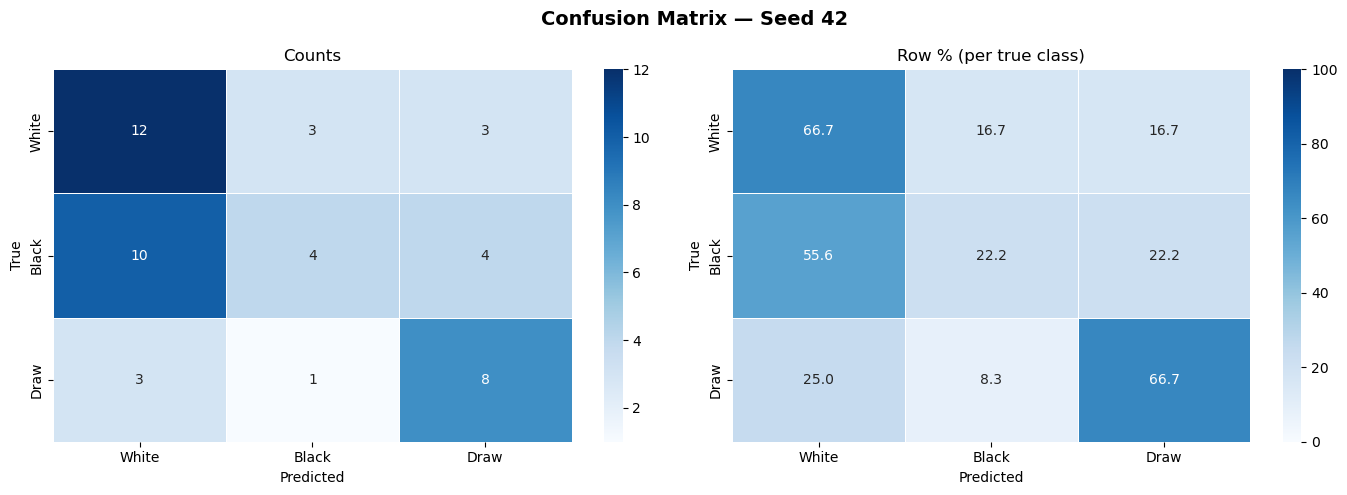

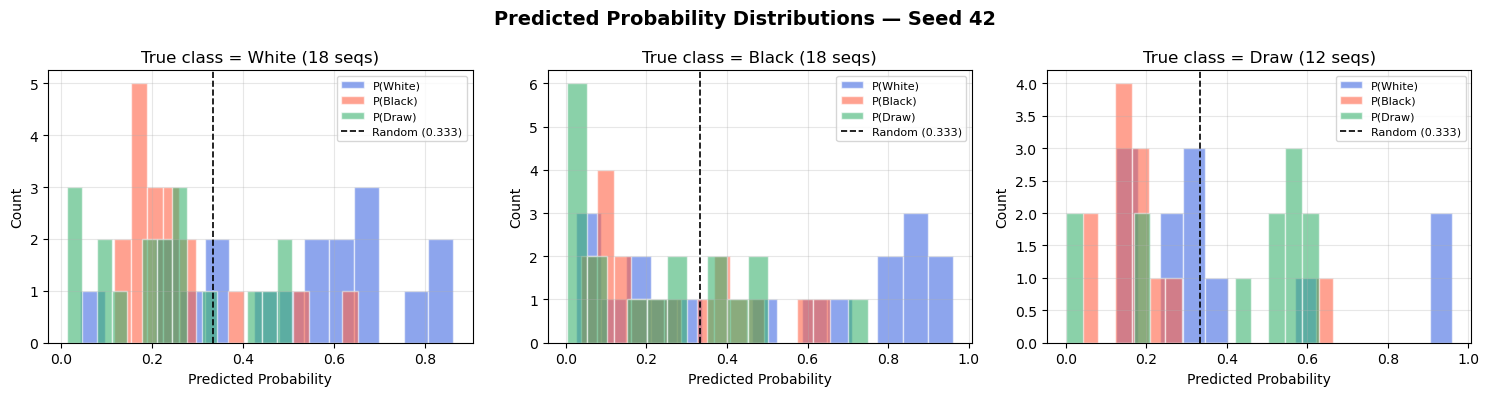


HARD VOTE
  Video 1: votes W=6 B=0 D=0  pred=White  true=Black  ✗
  Video 2: votes W=0 B=3 D=3  pred=Black  true=Black  ✓
  Video 3: votes W=4 B=1 D=1  pred=White  true=Black  ✗
  Video 4: votes W=4 B=2 D=0  pred=White  true=White  ✓
  Video 5: votes W=5 B=1 D=0  pred=White  true=White  ✓
  Video 6: votes W=3 B=0 D=3  pred=White  true=White  ✓
  Video 7: votes W=2 B=1 D=3  pred=Draw   true=Draw   ✓
  Video 8: votes W=1 B=0 D=5  pred=Draw   true=Draw   ✓

  Hard accuracy: 6/8 = 0.750

SOFT VOTE
  Video 1: avg W=0.84 B=0.12 D=0.04  pred=White  true=Black  ✗
  Video 2: avg W=0.15 B=0.39 D=0.46  pred=Draw   true=Black  ✗
  Video 3: avg W=0.54 B=0.26 D=0.20  pred=White  true=Black  ✗
  Video 4: avg W=0.48 B=0.30 D=0.22  pred=White  true=White  ✓
  Video 5: avg W=0.60 B=0.27 D=0.12  pred=White  true=White  ✓
  Video 6: avg W=0.46 B=0.19 D=0.35  pred=White  true=White  ✓
  Video 7: avg W=0.45 B=0.24 D=0.32  pred=White  true=Draw   ✗
  Video 8: avg W=0.35 B=0.16 D=0.49  pred=Draw   true=Draw 

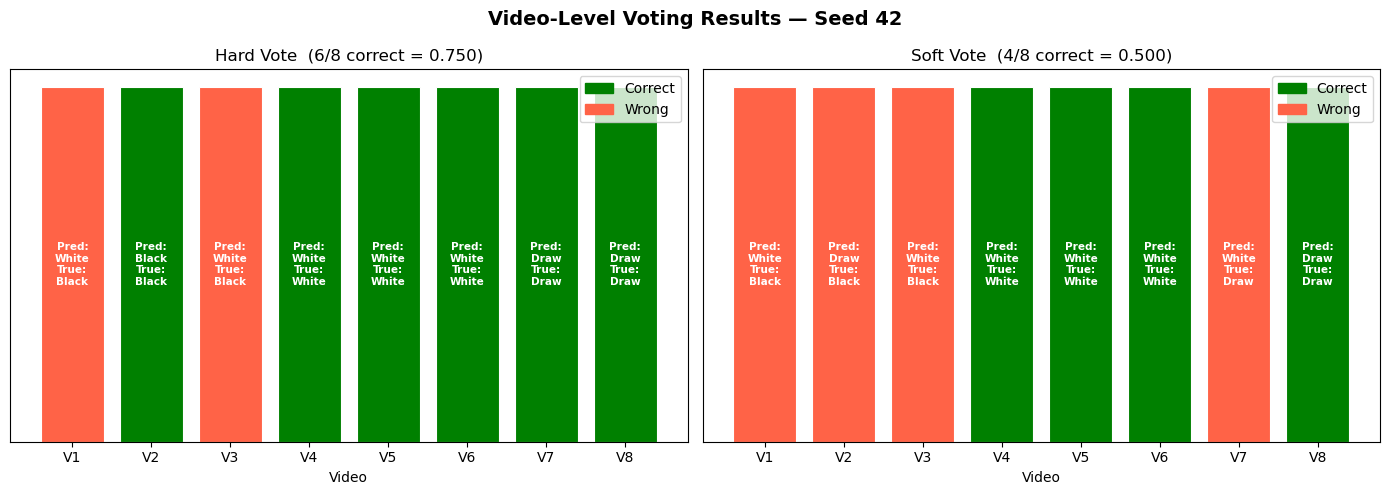


Seed 42: overall=0.500  W=0.667  B=0.222  D=0.667
           Hard=0.750  Soft=0.500

SEED 7
TCN parameters: 5,795
Training: TCN_seed7
Device:   cpu
Params:   5,795
 Epoch TrainLoss TrainAcc ValLoss ValAcc
     1    1.1412    0.253  1.0883  0.375 <- saved
     2    1.0536    0.413  1.1016  0.333
     3    1.0347    0.500  1.1523  0.312
     4    0.9835    0.531  1.1715  0.458 <- saved
     5    0.9704    0.549  1.1453  0.438
     6    0.9374    0.569  1.3360  0.396
     7    0.9267    0.562  1.2856  0.417
     8    0.9436    0.583  1.1674  0.312
     9    0.9171    0.597  1.2757  0.417
    10    0.8966    0.583  1.2751  0.479 <- saved
    11    0.9303    0.597  1.3195  0.458
    12    0.8801    0.639  1.1918  0.438
    13    0.8733    0.632  1.2497  0.500 <- saved
    14    0.8712    0.660  1.2790  0.458
    15    0.8837    0.594  1.1676  0.500
    16    0.8651    0.618  1.2149  0.479
    17    0.8623    0.604  1.2835  0.458
    18    0.8467    0.653  1.2234  0.438
    19    0.8549    

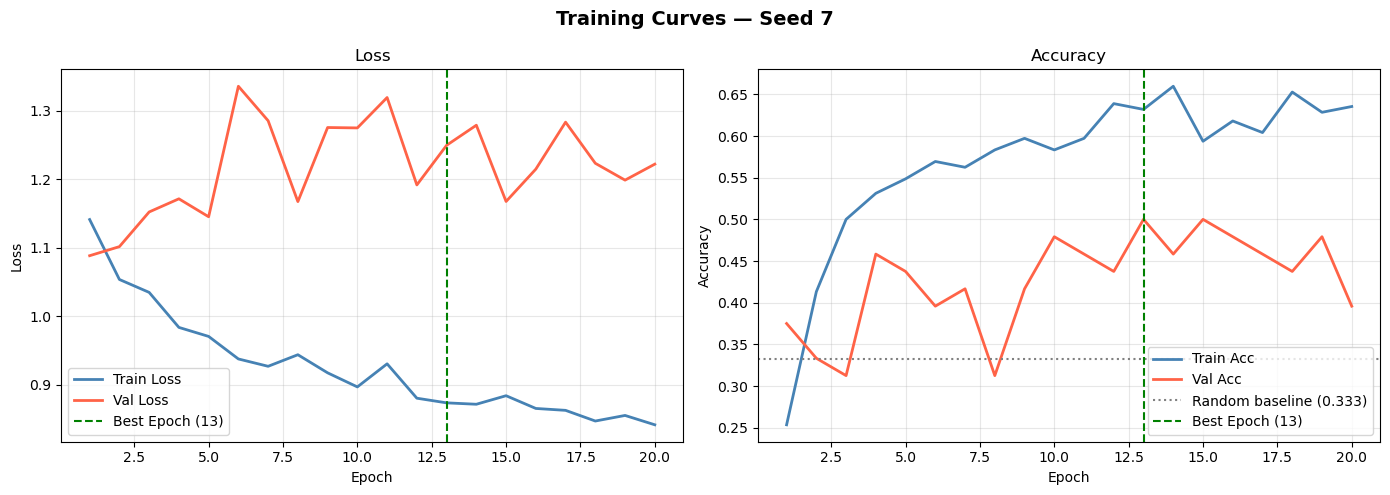


TEST RESULTS — TCN_seed7
Overall Accuracy: 0.500  (24/48 correct)

Per-class accuracy:
  White: 0.889  (18 sequences)
  Black: 0.278  (18 sequences)
  Draw : 0.250  (12 sequences)

Detailed predictions:
      True   Pred   White%   Black%   Draw% 
  ✗   Black  White    82.4%     7.5%   10.0%
  ✗   Black  White    75.4%    11.9%   12.7%
  ✗   Black  White    61.0%    22.5%   16.5%
  ✗   Black  White    67.6%    19.5%   12.8%
  ✗   Black  White    76.1%    12.7%   11.2%
  ✗   Black  White    73.4%    13.4%   13.3%
  ✗   Black  White    47.1%    38.9%   14.0%
  ✓   Black  Black    26.3%    53.9%   19.8%
  ✓   Black  Black    35.1%    54.1%   10.8%
  ✓   Black  Black    36.4%    46.3%   17.3%
  ✓   Black  Black     6.6%    55.7%   37.7%
  ✗   Black  Draw      9.3%    12.8%   77.9%
  ✗   Black  White    67.6%    18.0%   14.4%
  ✗   Black  White    73.4%    12.7%   13.9%
  ✗   Black  White    84.6%     6.5%    8.9%
  ✗   Black  White    59.2%    24.7%   16.1%
  ✓   Black  Black    37.7%    

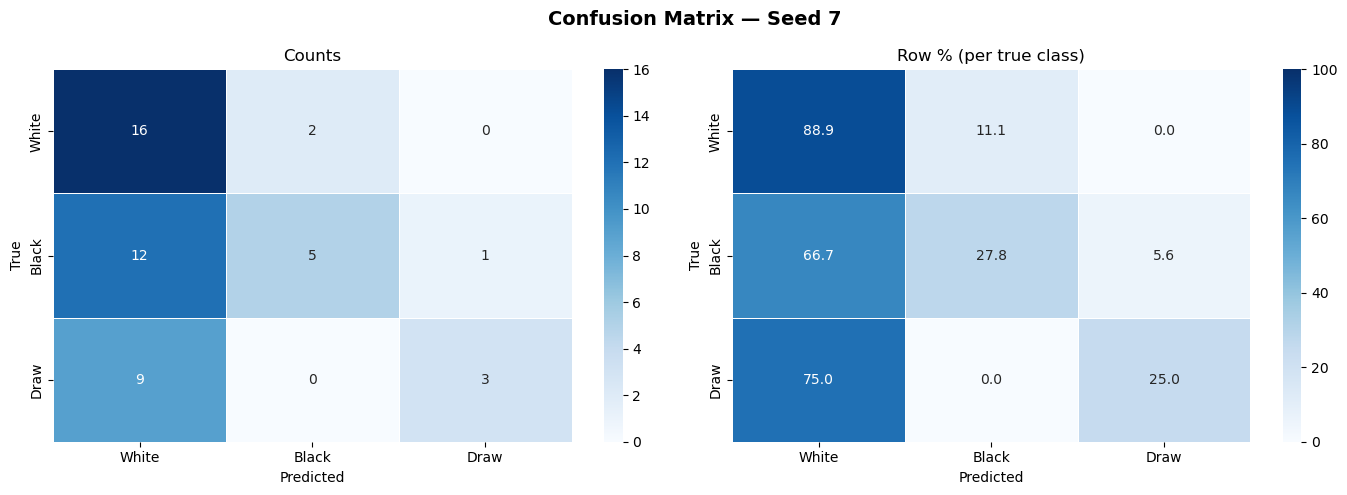

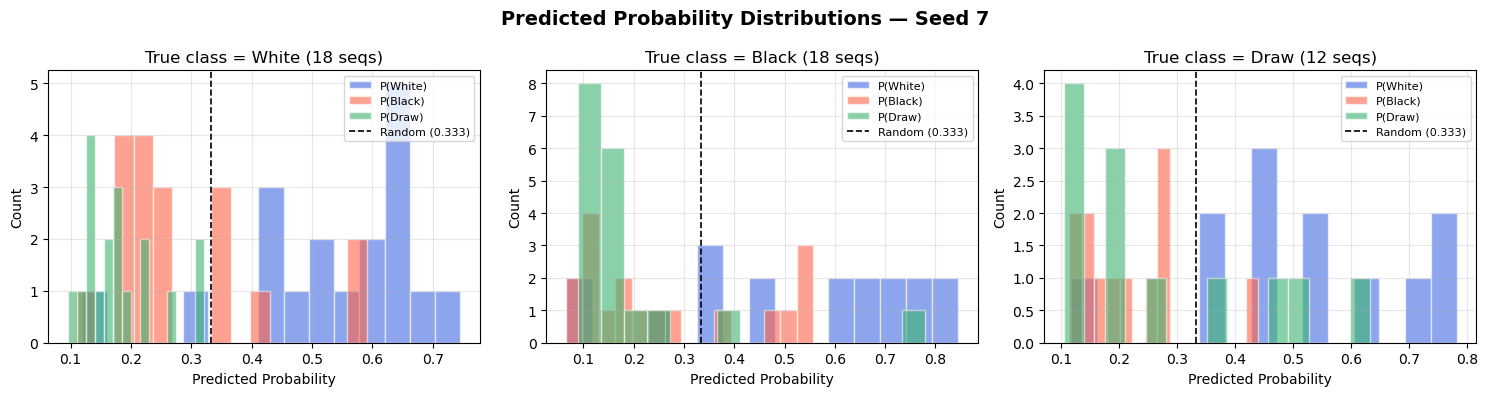


HARD VOTE
  Video 1: votes W=6 B=0 D=0  pred=White  true=Black  ✗
  Video 2: votes W=1 B=4 D=1  pred=Black  true=Black  ✓
  Video 3: votes W=5 B=1 D=0  pred=White  true=Black  ✗
  Video 4: votes W=5 B=1 D=0  pred=White  true=White  ✓
  Video 5: votes W=5 B=1 D=0  pred=White  true=White  ✓
  Video 6: votes W=6 B=0 D=0  pred=White  true=White  ✓
  Video 7: votes W=5 B=0 D=1  pred=White  true=Draw   ✗
  Video 8: votes W=4 B=0 D=2  pred=White  true=Draw   ✗

  Hard accuracy: 4/8 = 0.500

SOFT VOTE
  Video 1: avg W=0.73 B=0.15 D=0.13  pred=White  true=Black  ✗
  Video 2: avg W=0.27 B=0.44 D=0.30  pred=Black  true=Black  ✓
  Video 3: avg W=0.62 B=0.24 D=0.15  pred=White  true=Black  ✗
  Video 4: avg W=0.54 B=0.26 D=0.19  pred=White  true=White  ✓
  Video 5: avg W=0.50 B=0.36 D=0.14  pred=White  true=White  ✓
  Video 6: avg W=0.56 B=0.23 D=0.22  pred=White  true=White  ✓
  Video 7: avg W=0.55 B=0.23 D=0.22  pred=White  true=Draw   ✗
  Video 8: avg W=0.47 B=0.21 D=0.32  pred=White  true=Draw 

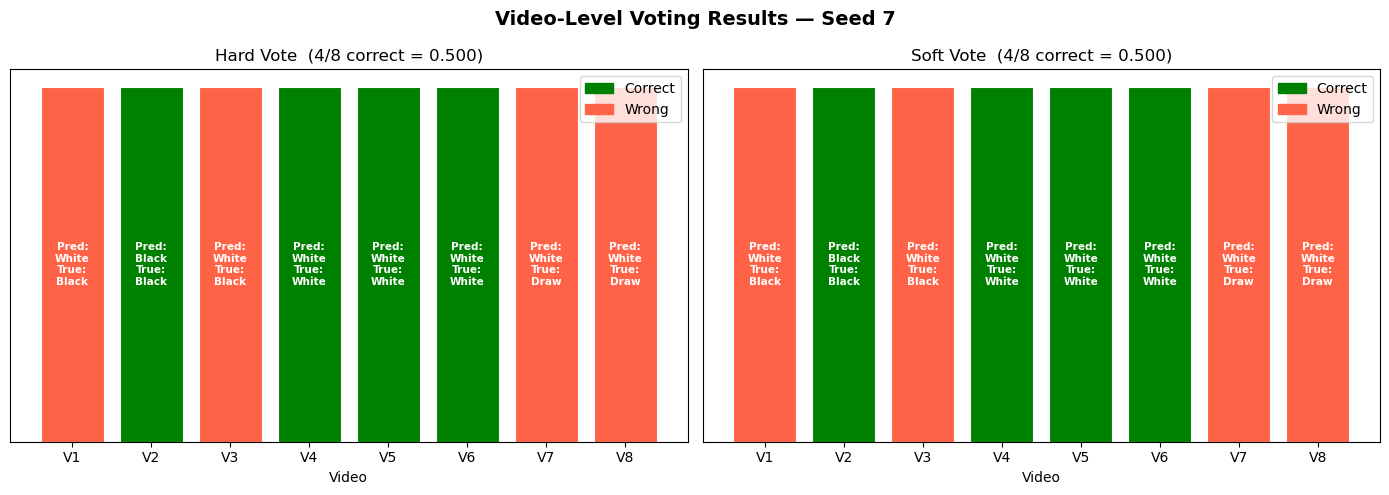


Seed 7: overall=0.500  W=0.889  B=0.278  D=0.250
           Hard=0.500  Soft=0.500

SEED 123
TCN parameters: 5,795
Training: TCN_seed123
Device:   cpu
Params:   5,795
 Epoch TrainLoss TrainAcc ValLoss ValAcc
     1    1.1237    0.424  1.0809  0.375 <- saved
     2    1.0408    0.462  1.0813  0.354
     3    1.0100    0.542  1.1044  0.250
     4    0.9853    0.542  1.1448  0.354
     5    0.9549    0.566  1.2592  0.479 <- saved
     6    0.9625    0.562  1.1139  0.417
     7    0.9342    0.566  1.2986  0.417
     8    0.9267    0.611  1.1612  0.417
     9    0.8915    0.590  1.1747  0.417
    10    0.8706    0.653  1.1858  0.417
    11    0.8901    0.604  1.1710  0.396
    12    0.8597    0.642  1.1631  0.438
    13    0.8568    0.635  1.3734  0.375
    14    0.8460    0.618  1.1843  0.417
    15    0.8634    0.611  1.2200  0.396
    16    0.8385    0.656  1.2159  0.375
    17    0.8218    0.646  1.1317  0.354
    18    0.8216    0.635  1.1317  0.354
    19    0.8153    0.642  1.1306  

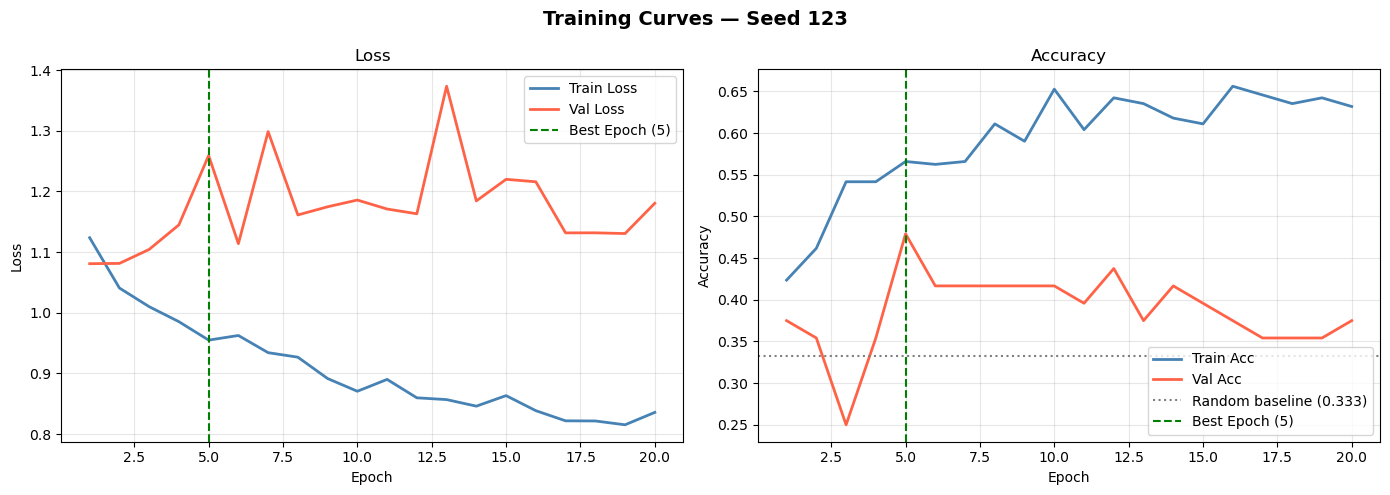


TEST RESULTS — TCN_seed123
Overall Accuracy: 0.479  (23/48 correct)

Per-class accuracy:
  White: 0.944  (18 sequences)
  Black: 0.222  (18 sequences)
  Draw : 0.167  (12 sequences)

Detailed predictions:
      True   Pred   White%   Black%   Draw% 
  ✗   Black  White    84.0%     9.3%    6.7%
  ✗   Black  White    76.3%    13.0%   10.7%
  ✗   Black  White    60.1%    25.3%   14.5%
  ✗   Black  White    66.1%    21.3%   12.6%
  ✗   Black  White    85.4%     9.3%    5.3%
  ✗   Black  White    72.8%    15.8%   11.4%
  ✗   Black  White    51.5%    33.7%   14.8%
  ✓   Black  Black    19.1%    57.0%   23.9%
  ✓   Black  Black    20.5%    60.1%   19.4%
  ✓   Black  Black    36.5%    41.7%   21.8%
  ✓   Black  Black     6.3%    57.5%   36.3%
  ✗   Black  Draw     16.4%    34.3%   49.3%
  ✗   Black  White    82.8%     9.8%    7.4%
  ✗   Black  White    80.0%    10.8%    9.2%
  ✗   Black  White    86.0%     8.1%    5.9%
  ✗   Black  White    59.0%    23.2%   17.8%
  ✗   Black  White    53.5%  

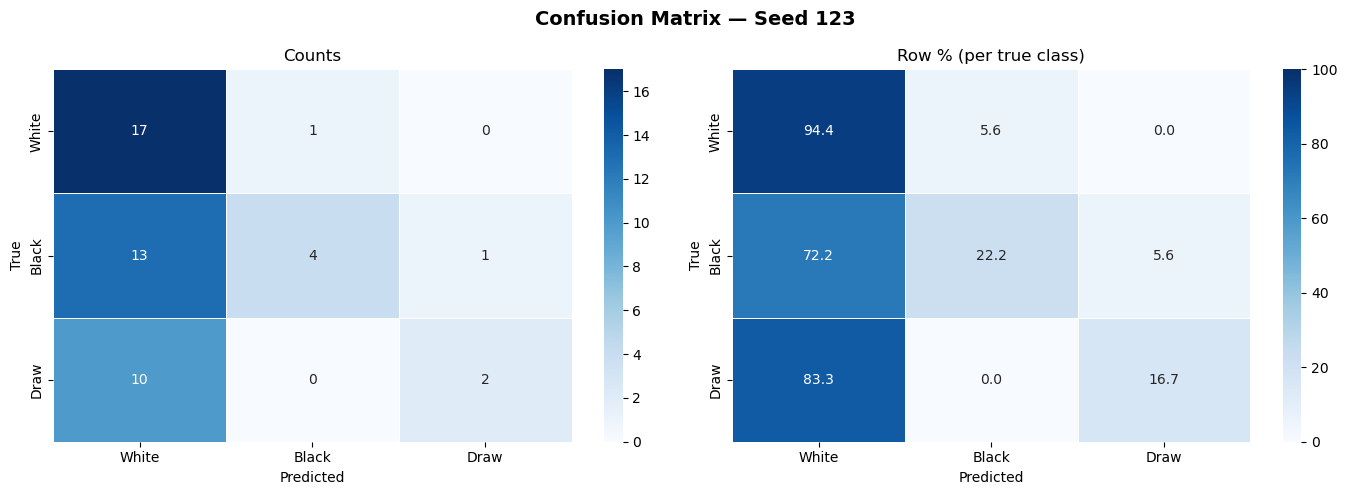

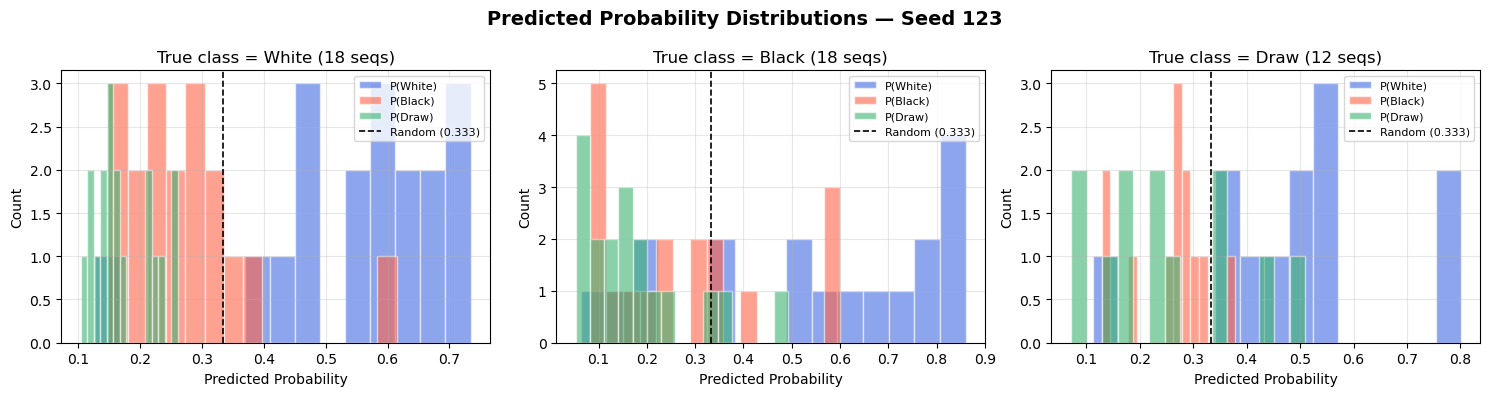


HARD VOTE
  Video 1: votes W=6 B=0 D=0  pred=White  true=Black  ✗
  Video 2: votes W=1 B=4 D=1  pred=Black  true=Black  ✓
  Video 3: votes W=6 B=0 D=0  pred=White  true=Black  ✗
  Video 4: votes W=5 B=1 D=0  pred=White  true=White  ✓
  Video 5: votes W=6 B=0 D=0  pred=White  true=White  ✓
  Video 6: votes W=6 B=0 D=0  pred=White  true=White  ✓
  Video 7: votes W=5 B=0 D=1  pred=White  true=Draw   ✗
  Video 8: votes W=5 B=0 D=1  pred=White  true=Draw   ✗

  Hard accuracy: 4/8 = 0.500

SOFT VOTE
  Video 1: avg W=0.74 B=0.16 D=0.10  pred=White  true=Black  ✗
  Video 2: avg W=0.25 B=0.47 D=0.28  pred=Black  true=Black  ✓
  Video 3: avg W=0.66 B=0.19 D=0.15  pred=White  true=Black  ✗
  Video 4: avg W=0.51 B=0.30 D=0.19  pred=White  true=White  ✓
  Video 5: avg W=0.58 B=0.28 D=0.14  pred=White  true=White  ✓
  Video 6: avg W=0.58 B=0.24 D=0.18  pred=White  true=White  ✓
  Video 7: avg W=0.53 B=0.26 D=0.21  pred=White  true=Draw   ✗
  Video 8: avg W=0.46 B=0.26 D=0.28  pred=White  true=Draw 

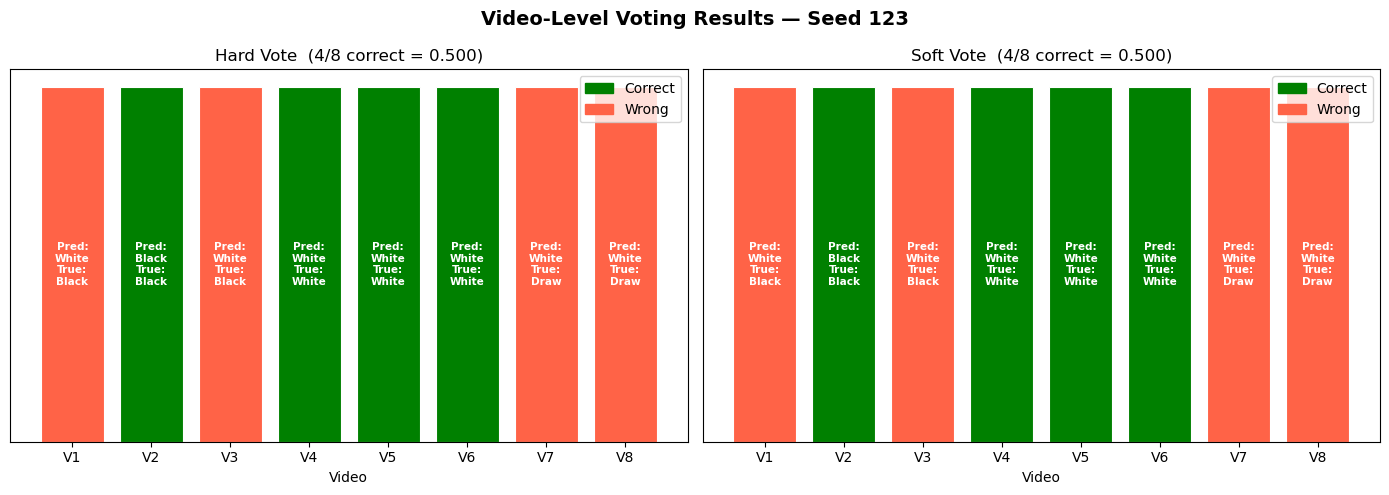


Seed 123: overall=0.479  W=0.944  B=0.222  D=0.167
           Hard=0.500  Soft=0.500

SEED 99
TCN parameters: 5,795
Training: TCN_seed99
Device:   cpu
Params:   5,795
 Epoch TrainLoss TrainAcc ValLoss ValAcc
     1    1.1201    0.351  1.1100  0.271 <- saved
     2    1.0648    0.531  1.0990  0.417 <- saved
     3    1.0358    0.521  1.0971  0.458 <- saved
     4    0.9997    0.576  1.2182  0.375
     5    0.9806    0.549  1.2854  0.375
     6    0.9658    0.552  1.2326  0.458
     7    0.9583    0.587  1.1431  0.458
     8    0.9602    0.573  1.2433  0.479 <- saved
     9    0.9578    0.604  1.4750  0.458
    10    0.9410    0.622  1.2963  0.438
    11    0.9271    0.611  1.1879  0.375
    12    0.8921    0.615  1.3517  0.500 <- saved
    13    0.8802    0.635  1.2975  0.396
    14    0.8740    0.611  1.4201  0.417
    15    0.8593    0.622  1.3866  0.396
    16    0.8666    0.632  1.2986  0.458
    17    0.8510    0.632  1.2529  0.458
    18    0.8298    0.639  1.2809  0.479
    19  

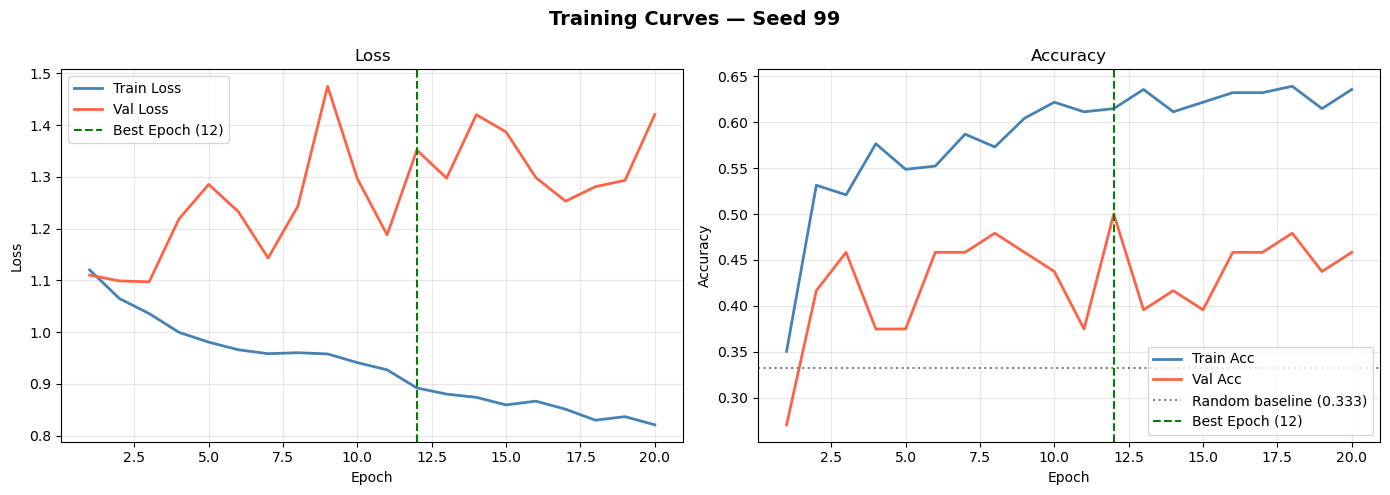


TEST RESULTS — TCN_seed99
Overall Accuracy: 0.500  (24/48 correct)

Per-class accuracy:
  White: 0.944  (18 sequences)
  Black: 0.278  (18 sequences)
  Draw : 0.167  (12 sequences)

Detailed predictions:
      True   Pred   White%   Black%   Draw% 
  ✗   Black  White    90.8%     6.4%    2.8%
  ✗   Black  White    77.9%    12.7%    9.4%
  ✗   Black  White    66.0%    21.3%   12.7%
  ✗   Black  White    73.8%    18.6%    7.6%
  ✗   Black  White    86.5%    11.1%    2.4%
  ✗   Black  White    82.1%    11.9%    6.0%
  ✗   Black  White    66.3%    25.8%    7.9%
  ✓   Black  Black    19.5%    68.2%   12.3%
  ✓   Black  Black    19.7%    69.8%   10.5%
  ✗   Black  White    43.3%    42.2%   14.4%
  ✓   Black  Black    10.7%    56.6%   32.7%
  ✗   Black  Draw     16.0%    19.9%   64.1%
  ✗   Black  White    80.7%    14.2%    5.1%
  ✗   Black  White    78.3%    12.9%    8.8%
  ✗   Black  White    89.9%     6.2%    3.9%
  ✗   Black  White    55.4%    22.2%   22.4%
  ✓   Black  Black    36.8%   

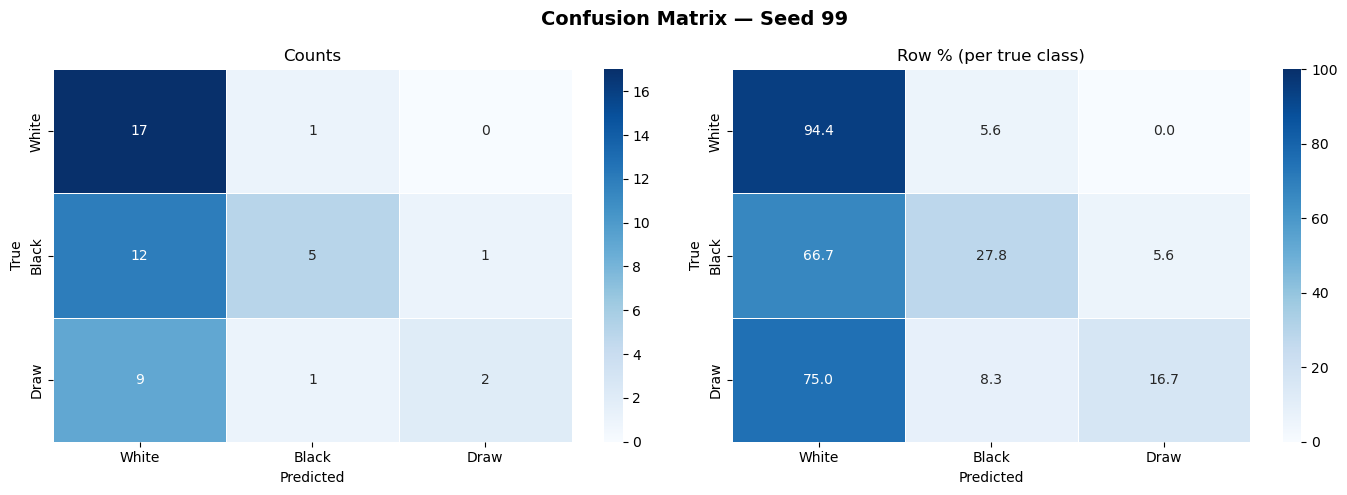

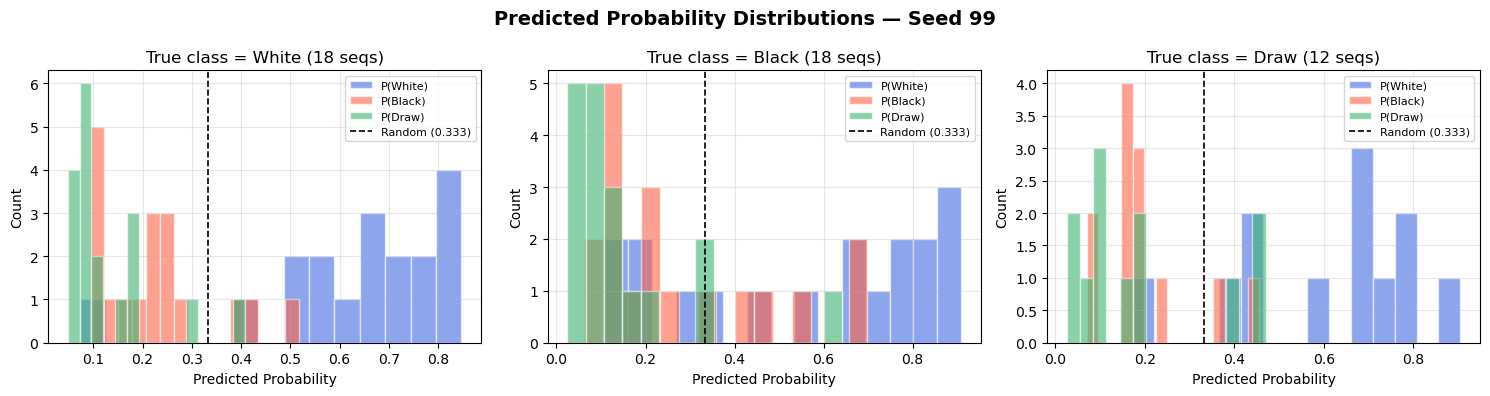


HARD VOTE
  Video 1: votes W=6 B=0 D=0  pred=White  true=Black  ✗
  Video 2: votes W=2 B=3 D=1  pred=Black  true=Black  ✓
  Video 3: votes W=4 B=2 D=0  pred=White  true=Black  ✗
  Video 4: votes W=5 B=1 D=0  pred=White  true=White  ✓
  Video 5: votes W=6 B=0 D=0  pred=White  true=White  ✓
  Video 6: votes W=6 B=0 D=0  pred=White  true=White  ✓
  Video 7: votes W=4 B=1 D=1  pred=White  true=Draw   ✗
  Video 8: votes W=5 B=0 D=1  pred=White  true=Draw   ✗

  Hard accuracy: 4/8 = 0.500

SOFT VOTE
  Video 1: avg W=0.80 B=0.14 D=0.07  pred=White  true=Black  ✗
  Video 2: avg W=0.29 B=0.47 D=0.24  pred=Black  true=Black  ✓
  Video 3: avg W=0.62 B=0.23 D=0.15  pred=White  true=Black  ✗
  Video 4: avg W=0.60 B=0.25 D=0.15  pred=White  true=White  ✓
  Video 5: avg W=0.67 B=0.25 D=0.08  pred=White  true=White  ✓
  Video 6: avg W=0.66 B=0.19 D=0.15  pred=White  true=White  ✓
  Video 7: avg W=0.62 B=0.23 D=0.15  pred=White  true=Draw   ✗
  Video 8: avg W=0.59 B=0.18 D=0.23  pred=White  true=Draw 

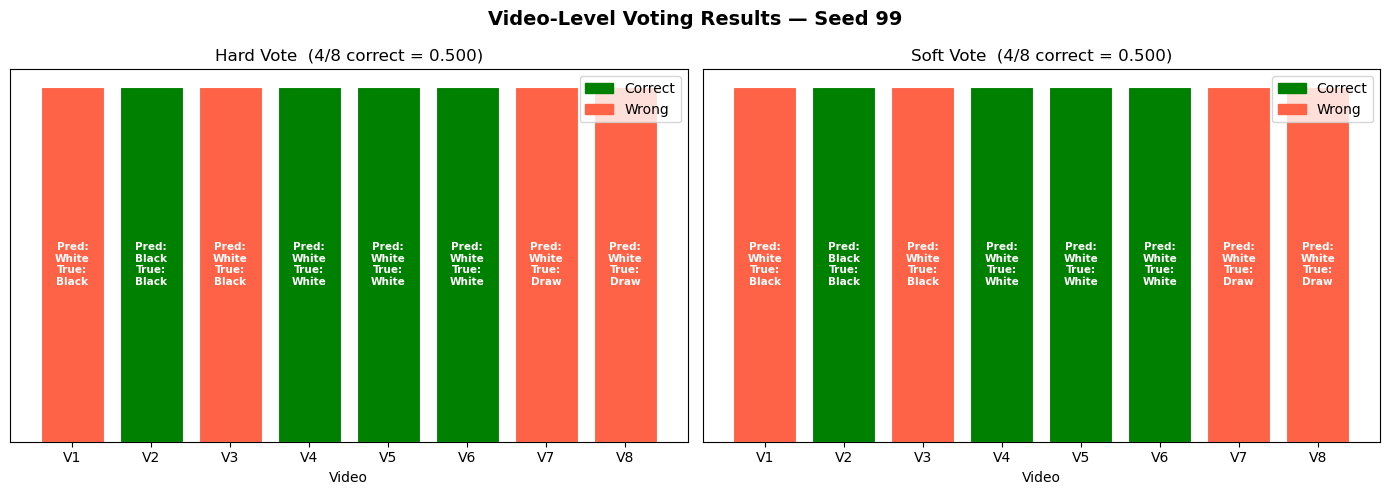


Seed 99: overall=0.500  W=0.944  B=0.278  D=0.167
           Hard=0.500  Soft=0.500

SEED 21
TCN parameters: 5,795
Training: TCN_seed21
Device:   cpu
Params:   5,795
 Epoch TrainLoss TrainAcc ValLoss ValAcc
     1    1.1185    0.538  1.0768  0.375 <- saved
     2    1.0658    0.455  1.0756  0.375
     3    1.0387    0.431  1.0721  0.354
     4    1.0067    0.528  1.1134  0.271
     5    0.9821    0.545  1.1951  0.458 <- saved
     6    0.9804    0.528  1.0812  0.354
     7    0.9704    0.531  1.0979  0.292
     8    0.9592    0.559  1.1791  0.458
     9    0.9401    0.576  1.1445  0.417
    10    0.8952    0.559  1.1074  0.312
    11    0.8913    0.562  1.0785  0.333
    12    0.8856    0.601  1.2242  0.458
    13    0.8867    0.597  1.1421  0.333
    14    0.8698    0.608  1.1106  0.312
    15    0.8675    0.597  1.1594  0.375
    16    0.8426    0.625  1.1373  0.312
    17    0.8298    0.597  1.1222  0.271
    18    0.8522    0.628  1.1528  0.312
    19    0.8353    0.618  1.1446  0

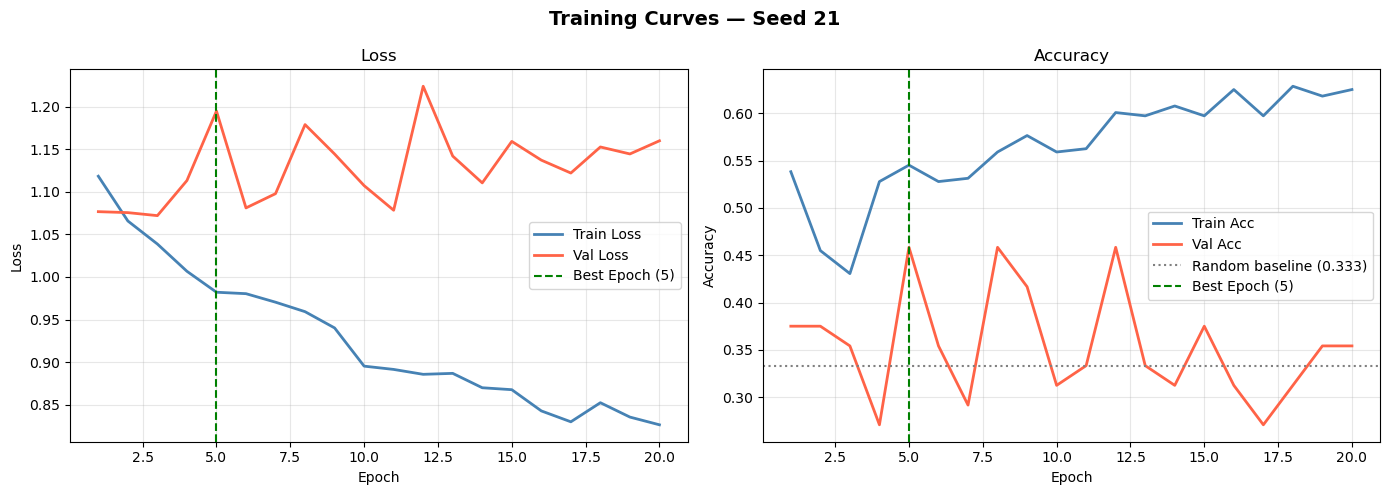


TEST RESULTS — TCN_seed21
Overall Accuracy: 0.458  (22/48 correct)

Per-class accuracy:
  White: 0.556  (18 sequences)
  Black: 0.278  (18 sequences)
  Draw : 0.583  (12 sequences)

Detailed predictions:
      True   Pred   White%   Black%   Draw% 
  ✗   Black  White    80.5%    10.7%    8.8%
  ✗   Black  White    76.3%    11.3%   12.4%
  ✗   Black  White    64.5%    19.2%   16.3%
  ✗   Black  White    55.4%    23.0%   21.6%
  ✗   Black  White    81.2%    11.4%    7.3%
  ✗   Black  White    70.0%    16.9%   13.2%
  ✓   Black  Black    31.5%    42.6%   26.0%
  ✓   Black  Black    13.4%    51.9%   34.7%
  ✓   Black  Black    15.2%    53.6%   31.2%
  ✓   Black  Black    16.6%    44.5%   38.9%
  ✗   Black  Draw      9.4%    42.9%   47.7%
  ✗   Black  Draw     14.9%    20.8%   64.3%
  ✗   Black  White    60.5%    21.7%   17.8%
  ✗   Black  White    71.8%    12.1%   16.2%
  ✗   Black  White    67.3%    18.8%   13.9%
  ✗   Black  White    58.2%    24.1%   17.7%
  ✓   Black  Black    27.8%   

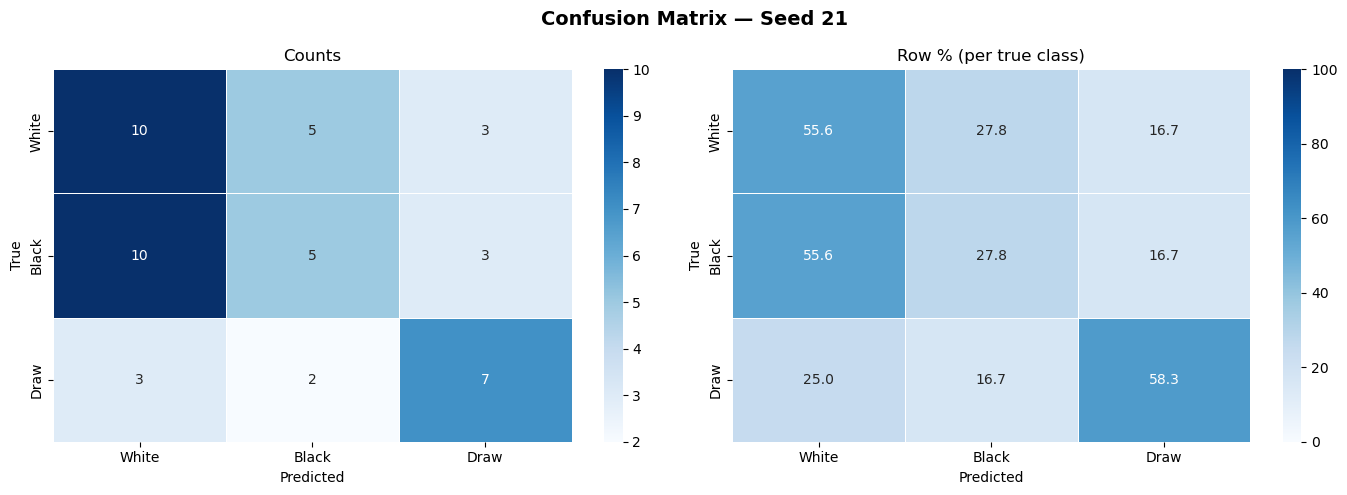

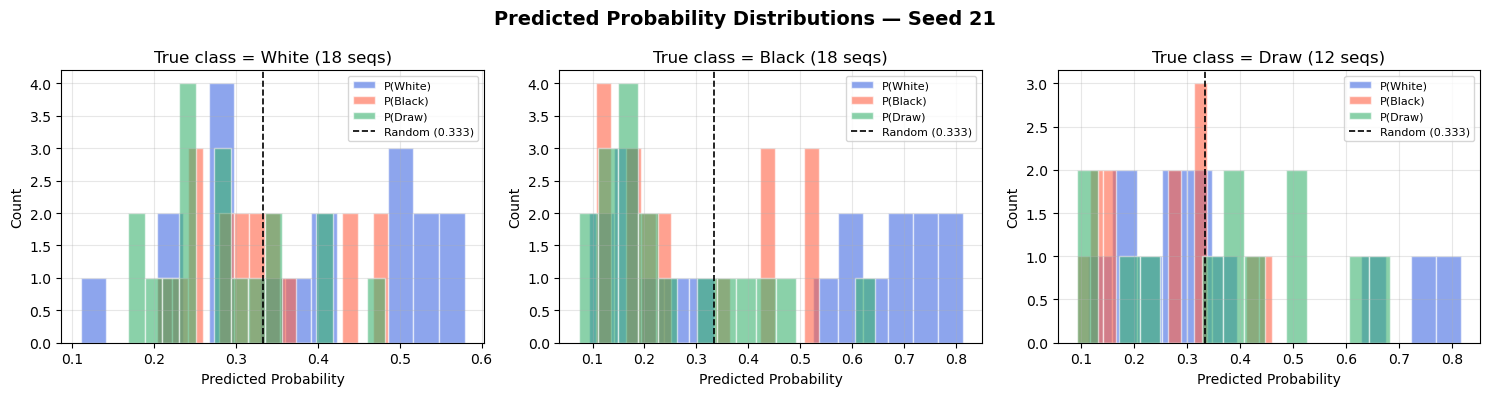


HARD VOTE
  Video 1: votes W=6 B=0 D=0  pred=White  true=Black  ✗
  Video 2: votes W=0 B=4 D=2  pred=Black  true=Black  ✓
  Video 3: votes W=4 B=1 D=1  pred=White  true=Black  ✗
  Video 4: votes W=3 B=3 D=0  pred=White  true=White  ✓
  Video 5: votes W=4 B=2 D=0  pred=White  true=White  ✓
  Video 6: votes W=3 B=0 D=3  pred=White  true=White  ✓
  Video 7: votes W=3 B=1 D=2  pred=White  true=Draw   ✗
  Video 8: votes W=0 B=1 D=5  pred=Draw   true=Draw   ✓

  Hard accuracy: 5/8 = 0.625

SOFT VOTE
  Video 1: avg W=0.71 B=0.15 D=0.13  pred=White  true=Black  ✗
  Video 2: avg W=0.17 B=0.43 D=0.40  pred=Black  true=Black  ✓
  Video 3: avg W=0.51 B=0.27 D=0.22  pred=White  true=Black  ✗
  Video 4: avg W=0.37 B=0.34 D=0.29  pred=White  true=White  ✓
  Video 5: avg W=0.44 B=0.33 D=0.23  pred=White  true=White  ✓
  Video 6: avg W=0.35 B=0.31 D=0.34  pred=White  true=White  ✓
  Video 7: avg W=0.50 B=0.24 D=0.26  pred=White  true=Draw   ✗
  Video 8: avg W=0.25 B=0.27 D=0.48  pred=Draw   true=Draw 

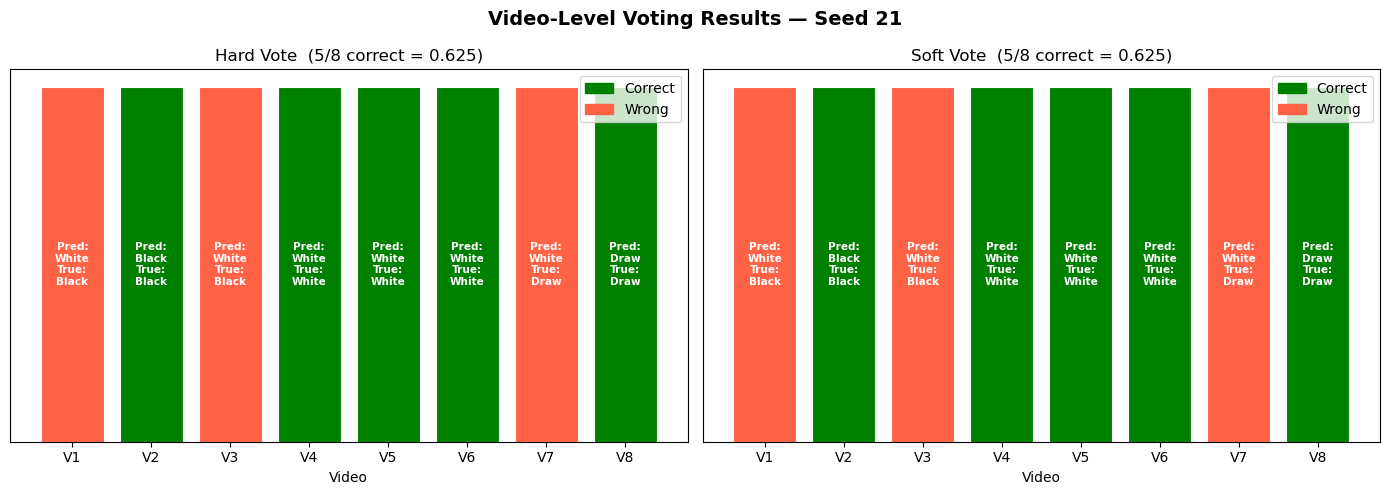


Seed 21: overall=0.458  W=0.556  B=0.278  D=0.583
           Hard=0.625  Soft=0.625

SUMMARY ACROSS 5 SEEDS
                   mean     std     min     max
--------------------------------------------------
Overall           0.487   0.017   0.458   0.500
White             0.800   0.159   0.556   0.944
Black             0.256   0.027   0.222   0.278
Draw              0.367   0.215   0.167   0.667
Hard Vote         0.575   0.100   0.500   0.750
Soft Vote         0.525   0.050   0.500   0.625

Thesis lines:
  Sequence : 0.487 ± 0.017
  Hard vote: 0.575 ± 0.100
  Soft vote: 0.525 ± 0.050


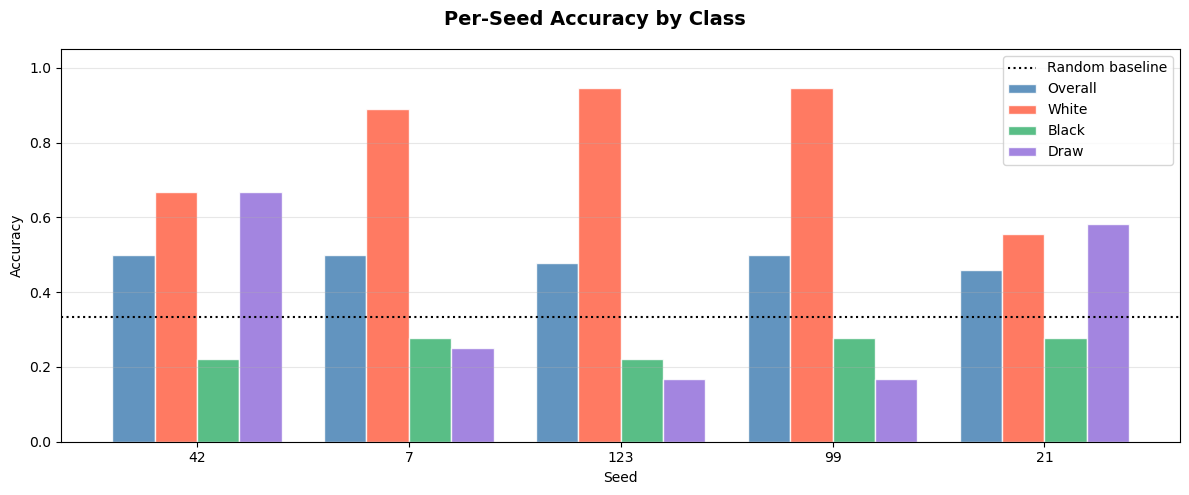

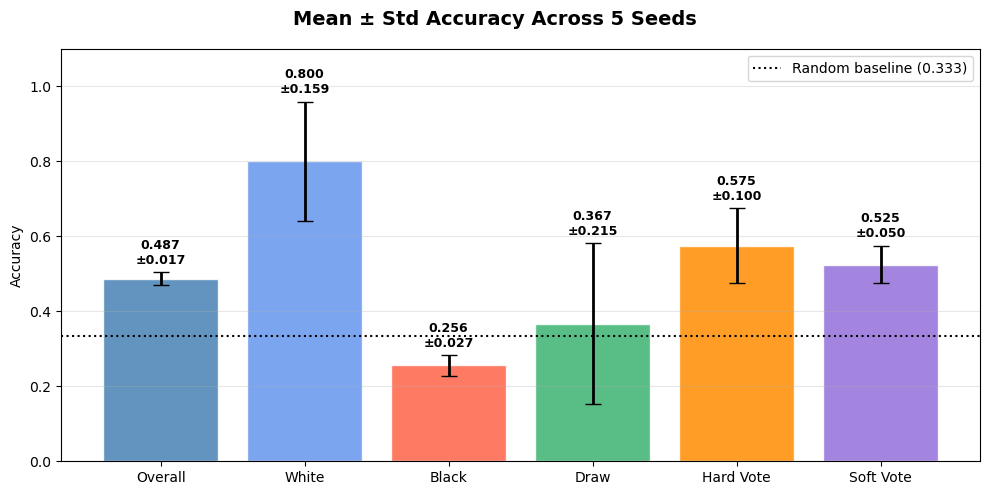

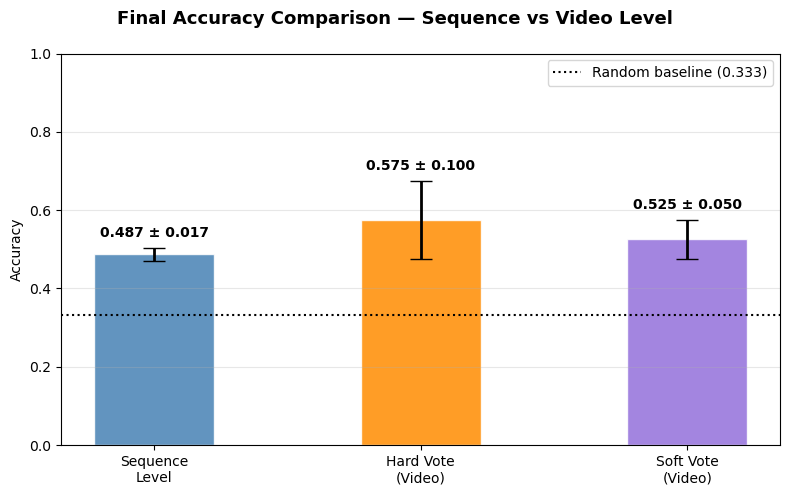

In [ ]:
# Load data
print("Loading data...")
X_train = np.load(os.path.join(DATA_FOLDER, 'X_train.npy'))
y_train = np.load(os.path.join(DATA_FOLDER, 'y_train.npy'))
X_test  = np.load(os.path.join(DATA_FOLDER, 'X_test.npy'))
y_test  = np.load(os.path.join(DATA_FOLDER, 'y_test.npy'))

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# Class weights
counts        = np.bincount(y_train, minlength=N_CLASSES).astype(float)
class_weights = torch.tensor(len(y_train) / (N_CLASSES * counts), dtype=torch.float32)

print(f"\nClass counts  — White: {int(counts[0])}, Black: {int(counts[1])}, Draw: {int(counts[2])}")
print(f"Class weights — White: {class_weights[0]:.3f}, Black: {class_weights[1]:.3f}, Draw: {class_weights[2]:.3f}")

# Datasets
train_dataset = FoosballDataset(X_train, y_train)
test_dataset  = FoosballDataset(X_test,  y_test)

# Seed loop
SEEDS = [42, 7, 123, 99, 21]

seed_results = {
    'overall'  : [],
    'white'    : [],
    'black'    : [],
    'draw'     : [],
    'hard_vote': [],
    'soft_vote': []
}

for seed in SEEDS:
    print(f"\n{'='*100}")
    print(f"SEED {seed}")
    print(f"{'='*100}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    tcn = TCN(n_features=N_FEATURES, n_classes=N_CLASSES)
    print(f"TCN parameters: {sum(p.numel() for p in tcn.parameters()):,}")

    tcn_path, history = train_model(tcn, train_loader, test_loader, class_weights, f'TCN_seed{seed}')

    # Graph 1 — training curves
    plot_training_curve(history, seed, MODEL_FOLDER)

    # evaluate
    acc, all_preds, all_labels, all_probs = evaluate_model(tcn, tcn_path, test_loader, f'TCN_seed{seed}')

    # Graph 2 — confusion matrix
    plot_confusion_matrix(all_preds, all_labels, seed, MODEL_FOLDER)

    # Graph 3 — probability distributions
    plot_probability_distribution(all_probs, all_labels, seed, MODEL_FOLDER)

    # per class accuracy
    white_acc = (all_preds[all_labels==0] == 0).mean()
    black_acc = (all_preds[all_labels==1] == 1).mean()
    draw_acc  = (all_preds[all_labels==2] == 2).mean()

    seed_results['overall'].append(acc)
    seed_results['white'].append(white_acc)
    seed_results['black'].append(black_acc)
    seed_results['draw'].append(draw_acc)

    # voting
    hard_acc = hard_vote(all_preds, all_labels)
    soft_acc = soft_vote(all_probs, all_labels)
    seed_results['hard_vote'].append(hard_acc)
    seed_results['soft_vote'].append(soft_acc)

    # Graph 4 — voting results per video
    plot_voting_results(all_preds, all_probs, all_labels, seed, MODEL_FOLDER)

    print(f"\nSeed {seed}: overall={acc:.3f}  W={white_acc:.3f}  B={black_acc:.3f}  D={draw_acc:.3f}")
    print(f"           Hard={hard_acc:.3f}  Soft={soft_acc:.3f}")


print(f" \n SUMMARY ACROSS {len(SEEDS)} SEEDS:")

print(f"{'':15}  {'mean':>6}  {'std':>6}  {'min':>6}  {'max':>6}")

for cls, key in [('Overall',   'overall'),
                 ('White',     'white'),
                 ('Black',     'black'),
                 ('Draw',      'draw'),
                 ('Hard Vote', 'hard_vote'),
                 ('Soft Vote', 'soft_vote')]:
    vals = seed_results[key]
    print(f"{cls:15}  "
          f"{np.mean(vals):6.3f}  "
          f"{np.std(vals):6.3f}  "
          f"{np.min(vals):6.3f}  "
          f"{np.max(vals):6.3f}")

print(f"\n Conclusion")
print(f"  Sequence : {np.mean(seed_results['overall']):.3f} \u00b1 {np.std(seed_results['overall']):.3f}")
print(f"  Hard vote: {np.mean(seed_results['hard_vote']):.3f} \u00b1 {np.std(seed_results['hard_vote']):.3f}")
print(f"  Soft vote: {np.mean(seed_results['soft_vote']):.3f} \u00b1 {np.std(seed_results['soft_vote']):.3f}")

# Graph 5 — per seed bars
plot_seed_summary(seed_results, SEEDS, MODEL_FOLDER)

# Graph 6 — mean +- std summary (thesis figure)
plot_mean_std_summary(seed_results, MODEL_FOLDER)

# Graph 7 — final 3-bar comparison
plot_final_comparison(seed_results, MODEL_FOLDER)